<a href="https://colab.research.google.com/github/vlhsilvia/TRABAJOS-PRACTICOS/blob/Silviamaster/edp2025_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

np.random.seed(142)

**Escuela de Primavera - Instituto de Altos Estudios Espaciales "Mario Gulich"**

# Convolutional Neural Networks (CNN)


![Redes Neuronales](images/cnn.png)

## Image Analysis with MLP

- **Does not leverage** the spatial structure of the image
- **Large number** of parameters
- **Not invariant** to translations
- **High computational** cost
- **Worse overall performance** compared to CNNs

### Does Not Leverage Spatial Structure

Images have a **2D structure**, and neighboring pixels are typically correlated.

An MLP requires you to **flatten the image into a 1D vector**, which destroys spatial information.

This means the MLP **cannot distinguish** between pixels that are close together or far apart, which is a serious problem for tasks like edge detection, shape recognition, or local pattern recognition.

### Large Number of Parameters

In MLPs, the number of neurons and connections **grows exponentially** with the input image size.

**Example**: For a 64×64 pixel image:
- Input layer: 4,096 neurons
- Hidden layer: 1,024 neurons
- **Parameters**: ~4 million weights to train

This creates models that are:
- **Extremely large**
- **Difficult to train**
- **High risk of overfitting**

### Not Invariant to Translations

If an object moves slightly in the image (e.g., a cat moves from center to corner), an MLP **does not generalize well** because it doesn't learn repeatable local patterns.

### High Computational Cost

Due to the large number of connections, training an MLP with moderately sized images becomes **computationally expensive** in both time and memory.

### Worse Overall Performance

In real-world tasks like image classification, MLPs tend to achieve **worse results than CNNs** because they cannot effectively capture complex visual features.

## Origins of CNNs

**Seminal paper**: [**"Receptive fields, binocular interaction and functional architecture in the cat's visual cortex"**](https://physoc.onlinelibrary.wiley.com/doi/10.1113/jphysiol.1962.sp006837), David Hubel and Torsten Wiesel (1962)

- Explored how the brain (of cats) processes visual information
- Recorded electrical activity of individual neurons in cat brains while showing them simple visual patterns like lines and edges
- Analyzed how these neurons responded to different stimuli
- **Won the Nobel Prize in Medicine in 1981**
- **Laid the foundation** for modern visual neuroscience and current techniques in computer vision

### What Did They Discover?

1. **Receptive Fields**
   - Each neuron in the visual cortex responds to a small region of the visual field
   - Neurons responded to lines and edges in specific orientations, not just points of light

2. **Simple and Complex Neurons**
   - **Simple neurons**: respond to specific lines in specific locations
   - **Complex neurons**: respond to orientations but are less dependent on exact location

3. **Columnar Organization**
   - Neurons in the cortex are organized in columns
   - All neurons within a column respond to the same line orientation
   - **Ocular dominance columns**: some neurons respond more to one eye than the other

### Why Is This Important?

- **First clear evidence** that visual perception is built step by step, from simple elements (lines) to more complex shapes
- Showed that the brain is not a "passive receiver" but has an **active, organized architecture**
- **Inspired artificial neural networks**, especially Convolutional Neural Networks (CNNs)

### Relationship with Computer Vision

Today, when we train neural networks to recognize objects in images, the system **mimics this hierarchy**:
- First detects **lines**
- Then detects **corners**  
- Then detects **shapes**

### What is a Receptive Field?

**In neuroscience**: The receptive field is the region of the visual field where a stimulus provokes a response in a specific neuron.

**In CNNs**: Each unit in a convolutional layer "sees" a portion of the input image. That portion is its receptive field.


### Visual Example Step by Step

Imagine an input image of size 32×32 pixels and a CNN with these layers:

1. **First Convolutional Layer**
   - 3×3 filters
   - Padding = 1
   - Stride = 1
   - **Receptive field**: 3×3 pixels

2. **Second Convolutional Layer**
   - 3×3 filters
   - Padding = 1
   - Stride = 1
   - **Receptive field**: 5×5 pixels (grows with depth)

3. **As we go deeper...**
   - The receptive field continues to grow
   - In deep layers, a single neuron can "see" a large portion or even the entire image

### First Paper Using a CNN

<table>
<tr>
<td>

<img align="left" src="images/first_cnn.png" alt="First CNN" width="2000" style="padding-left:0px">
    
</td>
<td>

This work **introduced the first convolutional network** trained with *backpropagation* for handwritten digit recognition, using data from US postal service zip codes.

**Key Contributions:**
- **Introduction of convolutional layers**, subsampling (pooling), and fully connected layers in a single architecture
- **End-to-end training** using error backpropagation
- **Demonstrated** that these networks could outperform traditional techniques in computer vision tasks

**Impact:**
- **Pioneered modern CNN architectures**
- **Established backpropagation** as viable for training deep networks
- **Laid foundation** for subsequent breakthroughs in computer vision

</td>
</tr>
</table>

---
## What is Signal Convolution?: 1D Convolutions

In signal analysis, a convolution of functions can be summarized as **filtering a signal using a filter function (*kernel*)**, and is mathematically expressed as (continuous version):

$$
(f * g)(t) = \int_{-\infty}^{\infty} f(t - \tau) \cdot g(\tau)  d\tau
$$

Imagine we have a **one-dimensional signal**, and to be concrete, let's think of an **audio wave**. This signal is a series of numbers that varies over time, like a wave.

Now, suppose we want to modify this signal, for example to:

- **Remove noise**
- **Highlight certain sounds**
- **Simulate an echo** or ambient effect

To perform this operation we use **signal convolution**. This is a mathematical operation that allows us to combine two signals:

- The **original signal**
- A special function called a "filter" (*kernel*), which defines how we want to transform the original signal

The result of the convolution is a **new signal**, which is a filtered version of the original signal using the chosen filter.


### Discrete Convolution in 1D

<table>
<tr>
<td>

The convolution of a signal \( x[n] \) with a filter \( h[n] \) is defined as:

$$
y[n] = (x * h)[n] = \sum_{k=-\infty}^{\infty} x[k] \cdot h[n - k]
$$

In practice (for finite signals), we use:

$$
y[n] = \sum_{k=0}^{K-1} x[k] \cdot h[n - k]
$$

**Where:**
- \( x[n] \): Input signal
- \( h[n] \): Filter/kernel
- \( y[n] \): Output signal
- \( K \): Length of the filter

</td>
<td>

<img align="left" src="images/filtro_1D.png" alt="Filtro 1D" width="1000" style="padding-left:100px">

</td>
</tr>
</table>

**Visual Interpretation:**
- The filter "slides" across the input signal
- At each position, we compute the **dot product** between the filter and the overlapping portion of the signal
- This process generates the output signal point by point


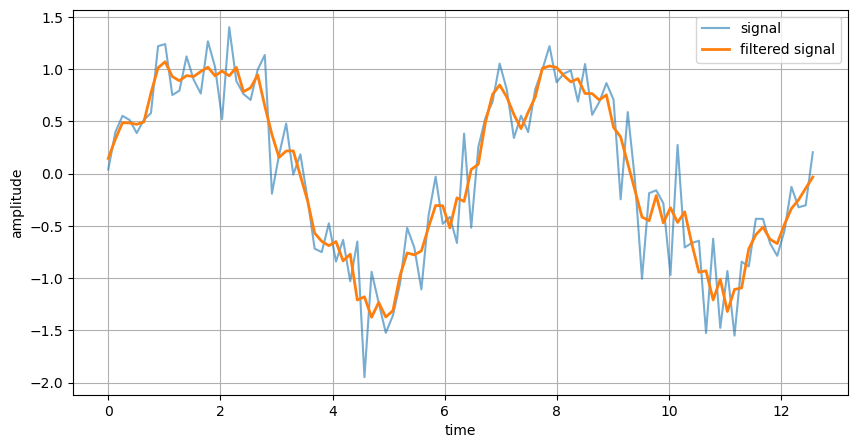

In [ ]:
# Generate a sample signal: sine + noise
x = np.linspace(0, 4 * np.pi, 100)
original_signal = np.sin(x)
noisy_signal = original_signal + np.random.normal(0, 0.3, size=original_signal.shape)

# Create a simple averaging filter (moving average)
kernel_size = 3
kernel = np.ones(kernel_size) / kernel_size

# Apply convolution
smoothed_signal = np.convolve(noisy_signal, kernel, mode='same')

# Plot the result
plt.figure(figsize=(10, 5))
plt.plot(x, noisy_signal, label='signal', alpha=0.6)
plt.plot(x, smoothed_signal, label='filtered signal', linewidth=2)
plt.xlabel('time'); plt.ylabel('amplitude')
plt.legend(); plt.grid(True)

### 2D Convolutions


Suppose we have a **grayscale image** represented by a matrix $I \in \mathbb{R}^{n \times n}$, and we have a filter of size $K \in \mathbb{R}^{(2k+1) \times (2k+1)}$.

The 2D convolution operation is defined as:

$$
G[i,j] = \sum_{l=-k}^{k} \sum_{m=-k}^{k}  K[l,m] \cdot I[i+l, j+m]
$$

**Where:**
- $I$: Input image matrix
- $K$: Filter/kernel matrix
- $G$: Output feature map
- $k$: Determines filter size (e.g., $k=1$ gives 3×3 filter)

<table>
<tr>
<td>

<img align="left" src="images/filtro_2D.png" alt="Filtro 2D" width="1000" style="padding-left:100px">

</td>
<td>

**Example Calculation:**

$\begin{align}
&(-1 \times 3) + (0 \times 0) + (1 \times 1) + \\
&(-2 \times 2) + (0 \times 6) + (2 \times 2) +\\
&(-1 \times 2) + (0 \times 4) + (1 \times 1) = -3
\end{align}$

**Process:**
- **Slide the filter** over the image
- At each position, compute the **element-wise product**
- **Sum all products** to get the output value
- Move to next position and repeat

</td>
</tr>
</table>

**Common Filter Types:**
- **Edge detection** (as shown in example)
- **Blur/smoothing** filters
- **Sharpening** filters
- **Feature extraction** filters

## Convolution Parameters: , Padding, and Kernel Size

These three parameters control how the convolution operation processes input data and determines the size of the output feature map.

### Kernel Size

**What it is:** The dimensions of the filter that slides over the input.

**Common sizes:** 1×1, 3×3, 5×5, 7×7

**Effects:**
- **Small kernels (e.g., 3×3):**
  - Capture local features (edges, corners)
  - Fewer parameters
  - Faster computation
  - Preserve spatial resolution

- **Large kernels (e.g., 7×7):**
  - Capture larger patterns
  - More parameters
  - Slower computation
  - Larger receptive field

**Formula impact:** Determines the range of the summation indices in the convolution operation.

### Stride

**What it is:** The step size at which the kernel moves across the input.

**Common values:** 1, 2, 3

**Effects:**
- **Stride = 1:** Kernel moves one pixel at a time
  - Dense sampling
  - Larger output size
  - More computation

- **Stride > 1:** Kernel jumps multiple pixels
  - Sparse sampling
  - Smaller output size
  - Less computation
  - Acts as a form of downsampling

**Output size formula:**
$$
\text{Output size} = \left\lfloor \frac{\text{Input size} - \text{Kernel size} + 2 \times \text{Padding}}{\text{Stride}} \right\rfloor + 1
$$

### Padding

**What it is:** Adding extra pixels around the input border before convolution.

**Types:**
- **Valid/No padding:** No extra pixels added
- **Same padding:** Add enough padding to maintain input size
- **Custom padding:** Specify exact padding amounts

**Effects:**
- **Preserves spatial dimensions** when using "same" padding
- **Controls information loss** at borders
- **Affects receptive field** coverage

**Common padding amounts:**
- For kernel size 3×3: Padding = 1 maintains size
- For kernel size 5×5: Padding = 2 maintains size

## Practical Guidelines

**Kernel Size:**
- Start with 3×3 for most applications
- Use 1×1 for dimensionality reduction
- Larger kernels for early layers to capture broader context

**Stride:**
- Use 1 for detailed feature extraction
- Use 2+ for downsampling instead of pooling layers

**Padding:**
- Use "same" padding to preserve spatial dimensions
- Use "valid" padding when you want natural size reduction

**Combination:** These parameters work together to control the trade-off between computational cost, feature preservation, and model capacity.

![Redes Neuronales](images/stride-1_padding-0.png)

![Redes Neuronales](images/stride-2_padding-0.png)

![Redes Neuronales](images/stride-1_padding-1.png)

## Filter Depth in CNNs: Multi-Channel Convolutions


In convolutional neural networks, filters extend through the **full depth** of the input volume, not just the spatial dimensions.

### Input Volume Structure

A typical input to a CNN layer has three dimensions:
- **Height** (H) - spatial dimension
- **Width** (W) - spatial dimension  
- **Channels** (C) - depth dimension

**Examples:**
- **RGB Image:** 3 channels (Red, Green, Blue)
- **Feature maps from previous layer:** 64, 128, 256, etc. channels
- **Medical imaging:** Multiple channels for different modalities

### Filter Dimensions

Each filter in a convolutional layer has dimensions:
- **Filter Height** (FH)
- **Filter Width** (FW)  
- **Filter Depth** (FC) - **MUST match input channels**

**Key Insight:** A single filter extends through **all input channels** simultaneously.

### Multiple Filters Create Depth

**Key Concept:** Each filter produces **one 2D feature map**. Multiple filters create multiple feature maps.

**Layer configuration:**
- **Input:** [H, W, C_in]
- **K filters:** Each of shape [FH, FW, C_in]
- **Output:** [H_out, W_out, K] - K channels from K filters


![Redes Neuronales](images/filtro_3d.png)

## Activation Functions for Output Layers

The choice of activation function in the output layer is **critical** and depends entirely on the type of problem you're solving.

The output layer activation transforms raw network outputs into meaningful predictions for your specific task.

### Classification Problems

### Binary Classification

**Use Case:** Predicting one of two classes (e.g., spam/not spam, cat/dog)

**Recommended Activation:** **Sigmoid**

**Function:**
$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

**Output Range:** (0, 1) - Interpretable as probability

**Loss Function:** Binary Cross-Entropy


### Multi-Class Classification (Single Label)

**Use Case:** Predicting one class from multiple exclusive options (e.g., digit recognition 0-9)

**Recommended Activation:** **Softmax**

**Function:**

$$
softmax(\vec{z}) = \left( \frac{e^{z_i}}{\sum_{j=1}^{n} e^{z_j}},i=1..n\right)
$$

**Properties:**

- Outputs sum to 1.0

- Each value represents probability of that class

- Automatically handles class competition

**Loss Function:** Categorical Cross-Entropy

### Multi-Label Classification

**Use Case:** Predicting multiple non-exclusive labels (e.g., image tags: "beach", "sunset", "people")

**Recommended Activation:** Sigmoid (on each output neuron)

**Approach:** Treat each class as independent binary classification

**Loss Function:** Binary Cross-Entropy


## Techniques to Prevent Overfitting - Dropout


Dropout is a **regularization technique** used to force the network to distribute learned representations across all neurons.

### What is Dropout?

Dropout **randomly "turns off"** a pre-specified fraction of units in a layer by setting their values to zero during training.

**Key Characteristics:**
- **Random selection** of neurons to drop
- **Different neurons** dropped each epoch
- **Applied only during training**
- **Disabled during inference/prediction**

### How Dropout Works

**During Training:**
- For each training example, randomly select neurons to drop
- Set their activations to zero
- Forward and backward pass use only the remaining neurons

**During Testing:**
- All neurons are active
- Layer outputs are scaled by dropout rate to maintain expected magnitude

### Why Dropout Prevents Overfitting

**Prevents Co-adaptation**

- Forces neurons to work independently

- Prevents reliance on specific "super neurons"

- Encourages distributed representations

**Approximates Ensemble Learning**

- Each forward pass uses a different "sub-network"

- Effectively trains an ensemble of networks

- Combines benefits of multiple architectures

**Adds Noise for Robustness**

- Introduces stochasticity during training

- Makes network less sensitive to specific neurons

- Improves generalization to unseen data


## Hands-on: designing a CNN using TensorFlow

In [ ]:
IMG_HEIGHT = 128
IMG_WIDTH = 128
IMG_CHANNELS = 3
BATCH_SIZE = 16

In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

kernel_initializer =  'he_uniform'  # also try 'he_normal' but model not converging...

inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))

x = Conv2D(8, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(inputs)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(4, (3, 3), activation='relu', kernel_initializer=kernel_initializer, padding='same')(x)
x = MaxPooling2D((2, 2))(x)
x = Flatten()(x)
x = Dense(512, activation='relu', kernel_initializer=kernel_initializer)(x)
x = Dense(256, activation='relu', kernel_initializer=kernel_initializer)(x)
outputs = Dense(1, activation='sigmoid', kernel_initializer=kernel_initializer)(x)

model = Model(inputs=[inputs],outputs=[outputs])


### Calculando la cantidad de parámetros


Tamaño de las imágenes de entrada 3 x 128 x 128.

1) *Primera capa convolucional*
- \# filters 8
- Kernel size 3x3
- Padding 1
- Stride 1

        3 (canales) x 3x3 (filter size) x 8 (filtros) + 8 (bias) = 224 parámetros a entrenar
        Tamaño de la imágen de salida 8 x 128 x 128

2) *Primera capa de pooling
- Kernel size 2x2
- Stride 2
- Padding 0

        No tiene parámetros para entrenar
        Tamaño de la imagen de salida: 8 x 64 x 64

3) *Segunda capa convolucional*
- \# filters 4
- Kernel size 3x3
- Padding 1
- Stride 1

        8 (canales) x 3x3 (filter size) x 4 (filtros) + 4 (bias) = 292 parámetros a entrenar
        Tamaño de la imágen de salida 4 x 64 x 64

4) *Segunda capa de pooling*
- Kernel size 2x2
- Stride 2
- Padding 0

        No tiene parámetros para entrenar
        Tamaño de la imagen de salida: 4 x 32 x 32

5) *Capa Flatten*

        Tamaño del **vector** de salida 4 x 32 x 32 = 4096

6) *Primera capa fully connected*
- \# de neuronas 512

        4096 (entradas) x 512 (neuronas) + 512 (bias) = 2097664  parámetros a entrenar

7) *Segunda capa fully connected*
-\# de neuronas 256

        512 (entradas) x 256 (neuronas) + 256 (bias) = 131328 parámetros a entrenar

8) *Capa de salida*
-\# de neuronas 2

        256 (entradas) x 1 (neuronas) + 1 = 257 parámetros a entrenar

**Cantidad total de parámetros a entrenar**

        224 + 292 + 2097664 + 131328 + 257 = 2229765



In [ ]:
LR = 0.0001
optimizer = Adam(LR)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 4)      │           292 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,229,765 (8.51 MB)

 Trainable params: 2,229,765 (8.51 MB)

 Non-trainable params: 0 (0.00 B)

## Image segmentation

Image segmentation can be formulated as the problem of classifying pixels
with semantic labels (semantic segmentation), or partitioning of individual objects
(instance segmentation), or both (panoptic segmentation). Semantic segmentation
performs pixel-level labeling with a set of object categories (e.g., human, car, tree,
sky) for all image pixels; thus, it is generally a more demanding undertaking
than whole-image classification, which predicts a single label for the entire image.
Instance segmentation extends the scope of semantic segmentation by detecting and
delineating each object of interest in the image (e.g., individual people).


### The U-Net Architecture

U-Net, introduced in 2015 for biomedical image segmentation, has become one of the most influential architectures in computer vision. Its name comes from its distinctive U-shaped design.


<img align="centre" src="images/UNet.png" alt="UNet" width="1000" style="padding-left:0px">


Input Image → Encoder (Contracting Path) → Bottleneck → Decoder (Expanding Path) → Output Segmentation Map

**Key Components**

1. Encoder (Contracting Path)

    Purpose: Extract features and capture context

    Structure: Series of convolutional and max-pooling layers

    What happens: Spatial dimensions decrease while feature depth increases

    Progressive downsampling reduces computational cost and increases receptive field

2. Bottleneck

    The bridge between encoder and decoder

    Contains the deepest features with the smallest spatial dimensions

    Captures the most abstract representations

3. Decoder (Expanding Path)

    Purpose: Precise localization and reconstruction

    Structure: Series of upsampling and convolutional layers

    What happens: Spatial dimensions increase while feature depth decreases

    Uses transposed convolutions or upsampling to recover spatial information

4. Skip Connections

    Direct connections between corresponding encoder and decoder layers

    Skip connections create information highways that bypass the bottleneck, preserving crucial details.

    Why they're crucial:

    - reserve spatial information lost during downsampling

    - Combine high-level semantic features with low-level spatial details

    - Enable precise boundary localization

    - Help with gradient flow during training



**U-Net advantages**

1. Excellent for Small Datasets

    - Originally designed for biomedical imaging with limited training data

    - Data augmentation strategies are easily applicable

    - Efficient learning from few examples

2. Precise Localization

    - Skip connections enable accurate boundary detection

    - Combines global context with local information

    - Perfect for tasks requiring pixel-level accuracy

3. Computational Efficiency

    - Symmetric structure balances computation

    - Progressive down/up sampling optimizes memory usage

    - Suitable for high-resolution images